In [84]:
import pandas as pd
import numpy as np
import re
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [85]:
def consolidar_colunas_duplicadas(df, nome_coluna):
    colunas = [c for c in df.columns if c == nome_coluna]
    if len(colunas) > 1:
        df[nome_coluna] = df[colunas].bfill(axis=1).iloc[:, 0]
        df = df.drop(columns=colunas[1:])
    return df

def converter_para_numerico(df, colunas):
    for col in colunas:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                        .str.extract(r"(\d+)", expand=False)
                        .astype(float)
            )
    return df

def normaliza_fase(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).upper()
    if "ALFA" in valor:
        return 0
    m = re.search(r"(\d+)", valor)
    return int(m.group(1)) if m else np.nan

def normaliza_idade(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor)
    m = re.search(r"(\d+)", valor)
    return float(m.group(1)) if m else np.nan

In [86]:
CAMINHO = r"../data/BASE_DE_DADOS_PEDE_2024_DATATHON.xlsx"

aba22 = pd.read_excel(CAMINHO, sheet_name="PEDE2022")
aba23 = pd.read_excel(CAMINHO, sheet_name="PEDE2023")
aba24 = pd.read_excel(CAMINHO, sheet_name="PEDE2024")

aba22["ano_origem"] = 2022
aba23["ano_origem"] = 2023
aba24["ano_origem"] = 2024

rename_2022 = {
    "RA": "id_aluno", "Idade 22" : "idade", "Turma": "turma",
    "Gênero": "genero", "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino", "Fase": "fase_atual",
    "Fase ideal": "fase_ideal", "Defas": "defasagem", "INDE 22": "inde",
    "IAN": "ian", "IDA": "ida", "IEG": "ieg", "IAA": "iaa",
    "IPS": "ips", "IPV": "ipv", "Matem": "nota_matematica",
    "Portug": "nota_portugues", "Inglês": "nota_ingles",
    "Atingiu PV": "atingiu_ponto_virada", "Indicado": "indicado_bolsa",
    "Destaque IDA": "obs_ida", "Destaque IEG": "obs_ieg",
    "Destaque IPV": "obs_ipv",
}

rename_2023 = {
    "RA": "id_aluno", "Idade" : "idade", "Turma": "turma",
    "Gênero": "genero", "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino", "Fase": "fase_atual",
    "Fase Ideal": "fase_ideal", "Defasagem": "defasagem",
    "INDE 2023": "inde", "IAN": "ian", "IDA": "ida", "IEG": "ieg",
    "IAA": "iaa", "IPS": "ips", "IPV": "ipv", "Mat": "nota_matematica",
    "Por": "nota_portugues", "Ing": "nota_ingles",
    "Atingiu PV": "atingiu_ponto_virada", "Indicado": "indicado_bolsa",
    "Destaque IDA": "obs_ida", "Destaque IEG": "obs_ieg",
    "Destaque IPV": "obs_ipv", "Destaque IPV.1": "obs_ipv"
}

rename_2024 = {
    "RA": "id_aluno", "Idade" : "idade", "Turma": "turma", "Gênero": "genero",
    "Ano ingresso": "ano_ingresso", "Instituição de ensino": "instituicao_ensino",
    "Fase": "fase_atual", "Fase Ideal": "fase_ideal", "Defasagem": "defasagem",
    "INDE 2024": "inde", "IAN": "ian", "IDA": "ida", "IEG": "ieg", "IAA": "iaa",
    "IPS": "ips", "IPV": "ipv", "Mat": "nota_matematica", "Por": "nota_portugues",
    "Ing": "nota_ingles", "Atingiu PV": "atingiu_ponto_virada",
    "Indicado": "indicado_bolsa", "Destaque IDA": "obs_ida",
    "Destaque IEG": "obs_ieg", "Destaque IPV": "obs_ipv"
}

aba22 = aba22.rename(columns=rename_2022)
aba23 = aba23.rename(columns=rename_2023)
aba24 = aba24.rename(columns=rename_2024)

aba23 = consolidar_colunas_duplicadas(aba23, "obs_ipv")

DADOS = pd.concat([aba22, aba23, aba24], ignore_index=True)

In [87]:
DADOS.columns = [c.lower() for c in DADOS.columns]

inds = ["ian","ida","ieg","iaa","ips","ipv","inde"]
notas = ["nota_matematica","nota_portugues","nota_ingles"]

DADOS = converter_para_numerico(DADOS, inds + notas)
DADOS["idade"] = DADOS["idade"].apply(normaliza_idade)
DADOS["fase_atual"] = DADOS["fase_atual"].apply(normaliza_fase)
DADOS["fase_ideal"] = DADOS["fase_ideal"].apply(normaliza_fase)

In [88]:
DADOS["risco_defasagem"] = np.where(
    (DADOS["ida"] < 5.5) | (DADOS["ian"] < 6),
    1, 0
)

In [89]:
df = DADOS.copy()

1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos 
alunos (IAN) e como ele evolui ao longo do ano?

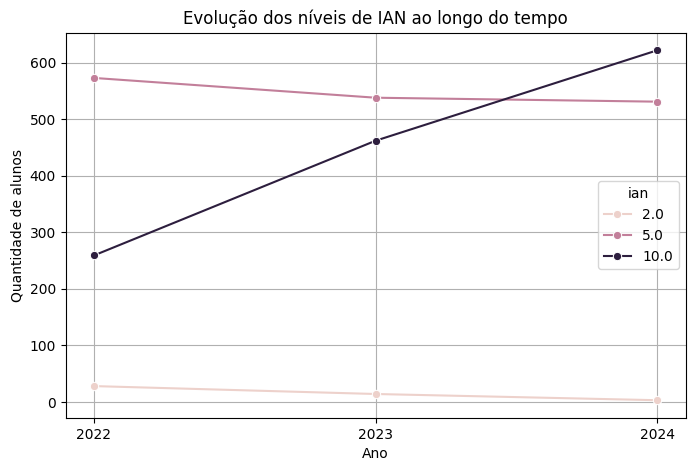

In [90]:
df['ano_origem'] = pd.to_numeric(df['ano_origem'], errors='coerce')
df['ano_origem'] = df['ano_origem'].astype(int)

df_ian_ano = df.groupby(['ano_origem','ian']).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.lineplot(data=df_ian_ano, x='ano_origem', y='count', hue='ian', marker='o')

plt.xticks(sorted(df_ian_ano['ano_origem'].unique()))

plt.title('Evolução dos níveis de IAN ao longo do tempo')
plt.xlabel('Ano')
plt.ylabel('Quantidade de alunos')
plt.grid()
plt.show()

2. Desempenho acadêmico (IDA): O desempenho acadêmico médio 
(IDA) está melhorando, estagnado ou caindo ao longo das fases e anos? 

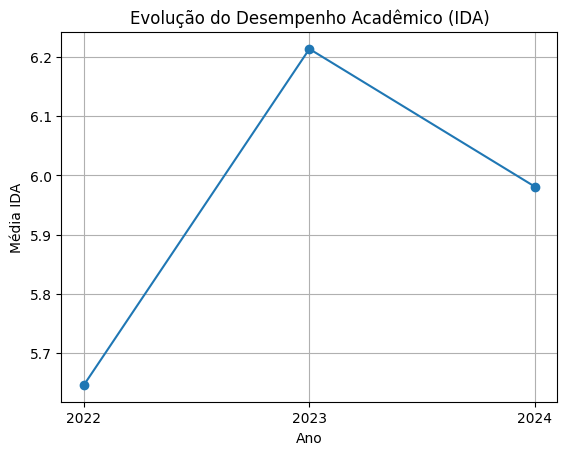

In [91]:
df["ano_origem"] = df["ano_origem"].astype(str).str.extract(r'(\d{4})')[0]
df["ano_origem"] = pd.to_numeric(df["ano_origem"], errors="coerce")

df_ida = df.groupby('ano_origem')['ida'].mean().reset_index()

df_ida = df_ida.dropna()
df_ida["ano_origem"] = df_ida["ano_origem"].astype(int)

plt.figure()
plt.plot(df_ida['ano_origem'], df_ida['ida'], marker='o')

plt.xticks(sorted(df_ida["ano_origem"].unique()))

plt.title('Evolução do Desempenho Acadêmico (IDA)')
plt.xlabel('Ano')
plt.ylabel('Média IDA')
plt.grid()

plt.show()

3. Engajamento nas atividades (IEG): O grau de engajamento dos 
alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e 
do ponto de virada (IPV)?

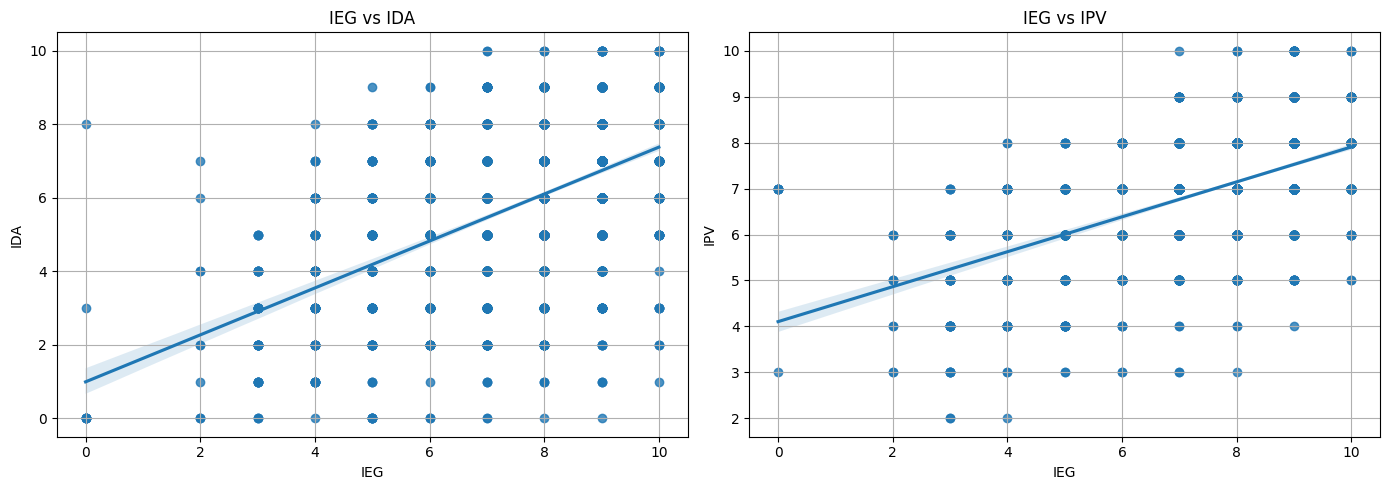

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='ieg', y='ida', ax=axes[0])
axes[0].set_title('IEG vs IDA')
axes[0].set_xlabel('IEG')
axes[0].set_ylabel('IDA')
axes[0].grid()

sns.regplot(data=df, x='ieg', y='ipv', ax=axes[1])
axes[1].set_title('IEG vs IPV')
axes[1].set_xlabel('IEG')
axes[1].set_ylabel('IPV')
axes[1].grid()

plt.tight_layout()
plt.show()

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos 
(IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)? 

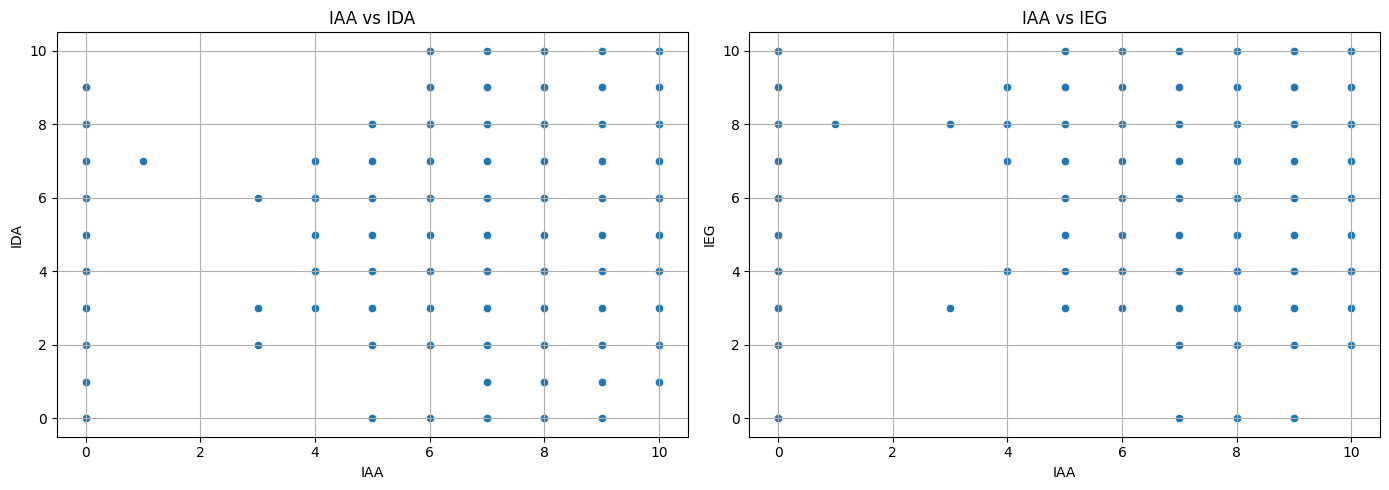

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='iaa', y='ida', ax=axes[0])
axes[0].set_title('IAA vs IDA')
axes[0].set_xlabel('IAA')
axes[0].set_ylabel('IDA')
axes[0].grid()

sns.scatterplot(data=df, x='iaa', y='ieg', ax=axes[1])
axes[1].set_title('IAA vs IEG')
axes[1].set_xlabel('IAA')
axes[1].set_ylabel('IEG')
axes[1].grid()

plt.tight_layout()
plt.show()

5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que 
antecedem quedas de desempenho acadêmico ou de engajamento?

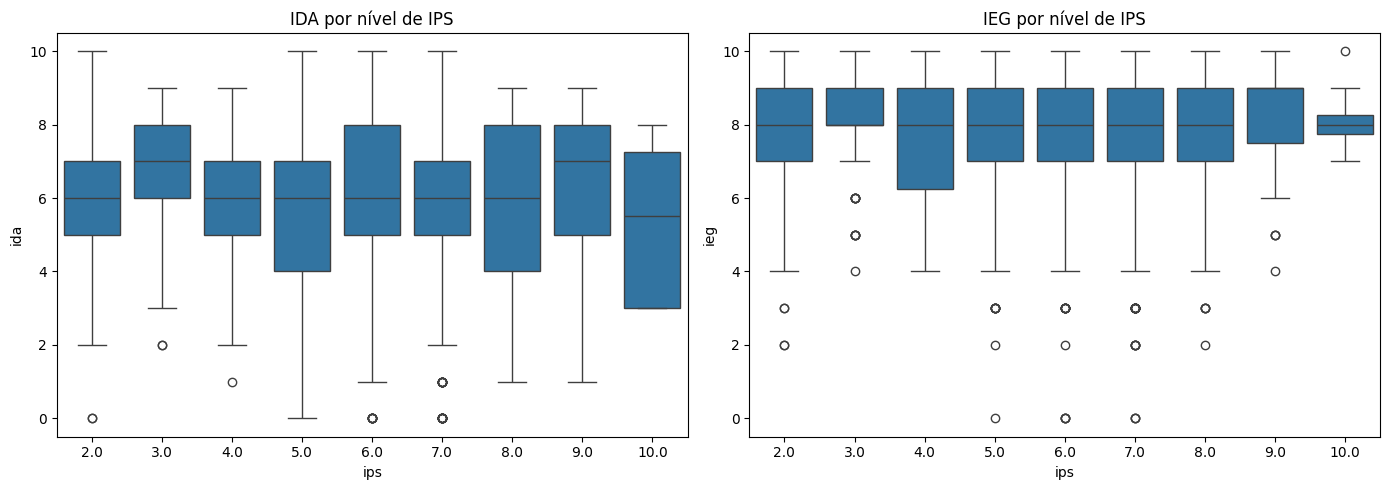

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x="ips", y="ida", ax=axes[0])
axes[0].set_title("IDA por nível de IPS")

sns.boxplot(data=df, x="ips", y="ieg", ax=axes[1])
axes[1].set_title("IEG por nível de IPS")

plt.tight_layout()
plt.show()

6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas 
(IPP) confirmam ou contradizem a defasagem identificada pelo IAN? 

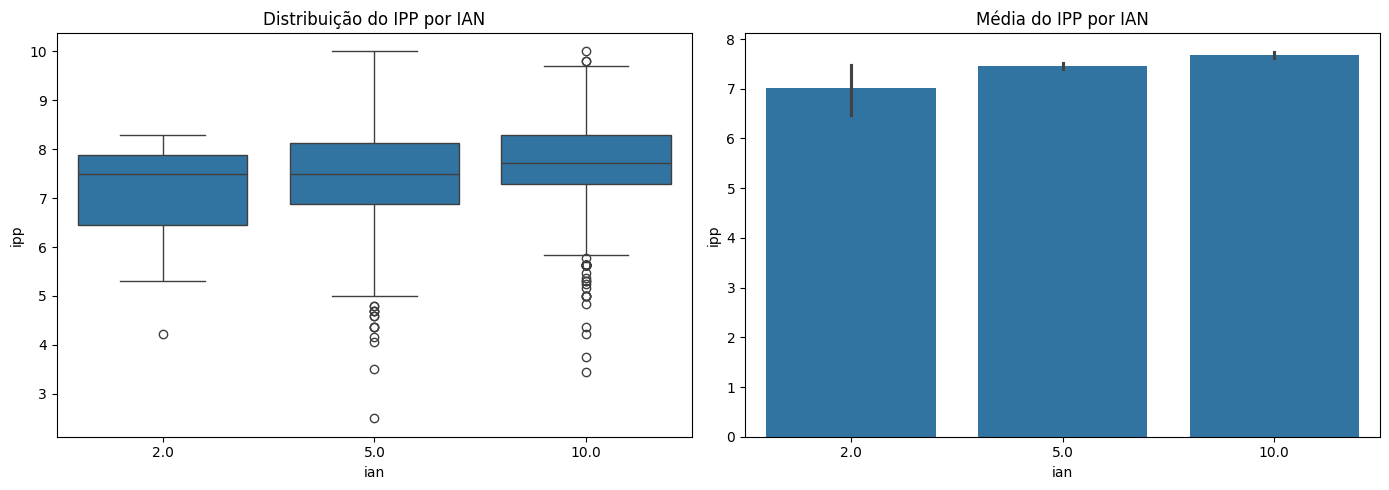

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='ian', y='ipp', ax=axes[0])
axes[0].set_title('Distribuição do IPP por IAN')

sns.barplot(data=df, x='ian', y='ipp', ax=axes[1])
axes[1].set_title('Média do IPP por IAN')

plt.tight_layout()
plt.show()

7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, 
emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

<Axes: >

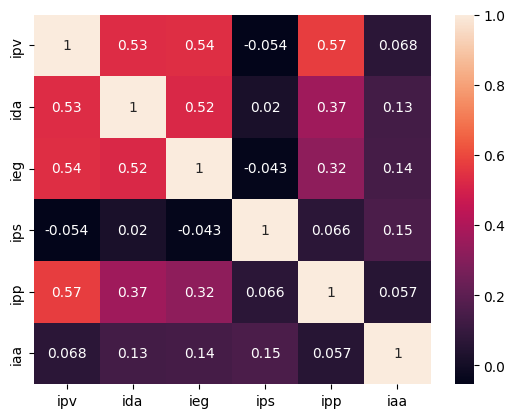

In [96]:
sns.heatmap(df[['ipv','ida','ieg','ips','ipp','iaa']].corr(), annot=True)

8. Multidimensionalidade dos indicadores: Quais combinações de 
indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

<Axes: >

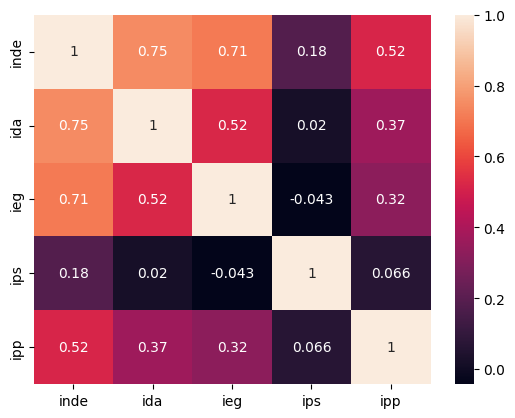

In [97]:
sns.heatmap(df[['inde','ida','ieg','ips','ipp']].corr(), annot=True)

10. Efetividade do programa: Os indicadores mostram melhora 
consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e 
Topázio), confirmando o impacto real do programa?

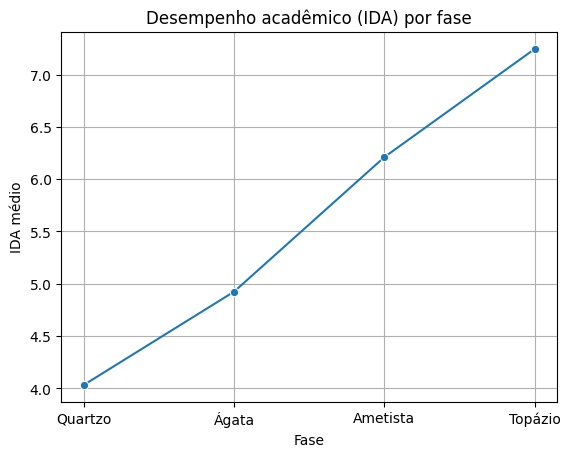

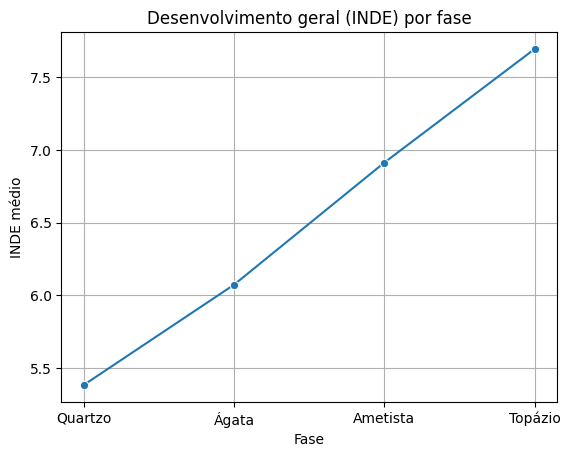

In [98]:
colunas_pedra = ["pedra 20", "pedra 21", "pedra 22", "pedra 23", "pedra 2023", "pedra 2024"]

df_pedra = df.melt(
    id_vars=["id_aluno"],
    value_vars=colunas_pedra,
    var_name="ano",
    value_name="pedra"
)

df_pedra = df_pedra.dropna(subset=["pedra"])

df_plot = df_pedra.merge(
    df[["id_aluno", "ida", "inde"]],
    on="id_aluno",
    how="left"
)

ordem = ["Quartzo", "Ágata", "Ametista", "Topázio"]

df_plot = df_plot[df_plot["pedra"].isin(ordem)]

df_plot["pedra"] = pd.Categorical(df_plot["pedra"], categories=ordem, ordered=True)

df_grouped = df_plot.groupby("pedra")[["ida", "inde"]].mean().reset_index()

plt.figure()
sns.lineplot(data=df_grouped, x="pedra", y="ida", marker="o")
plt.title("Desempenho acadêmico (IDA) por fase")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.grid()
plt.show()

plt.figure()
sns.lineplot(data=df_grouped, x="pedra", y="inde", marker="o")
plt.title("Desenvolvimento geral (INDE) por fase")
plt.xlabel("Fase")
plt.ylabel("INDE médio")
plt.grid()
plt.show()